In [129]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [ ]:
tickets = pd.read_csv('../data/_api/tickets.csv')
airlines_russia = pd.read_csv('../data/_api/airlines_russia.csv')
cities = pd.read_csv('../data/_api/cities-aviasales.csv')
cities_prepared = pd.read_csv('../data/_api/cities_prepared.csv')

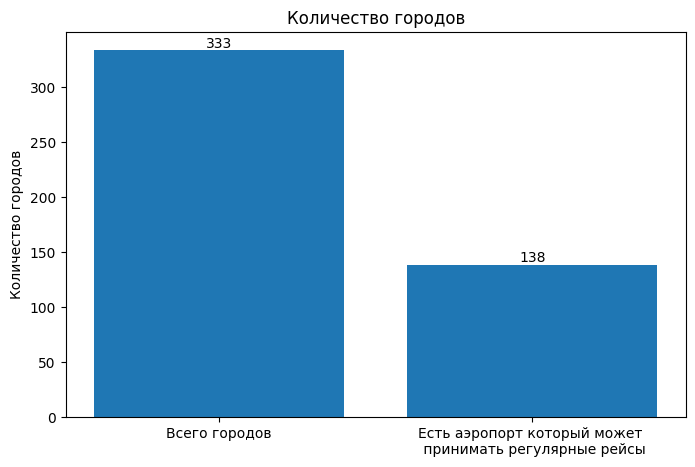

In [131]:
labels = ['Всего городов', 'Есть аэропорт который может \n принимать регулярные рейсы']
values = [len(cities), len(cities_prepared)]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)

plt.title('Количество городов')
plt.ylabel('Количество городов')

for i, v in enumerate(values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [132]:
tickets.dropna(inplace=True)
tickets = tickets[(tickets['distance'] != 0) & (tickets['duration'] != 0)]

In [133]:
tickets_copy = tickets.copy()
tickets_copy = tickets_copy[(tickets_copy['market'] == 'ru') & (tickets_copy['currency'] == 'rub')]

tickets_copy = (
    tickets_copy
    .sort_values('duration')
    .drop_duplicates(subset='destination', keep='first')
)
tickets_copy

,depart_date,origin,destination,gate,trip_class,value,duration,distance,market,currency,rate
133580,2026-06-20,MOW,CEE,Вэртас,0,6500,50,370,ru,rub,1.0
149052,2026-06-04,MOW,TBW,Rusline,0,3898,65,419,ru,rub,1.0
13147,2026-06-04,MOW,GOJ,Kupi.com,0,6085,75,396,ru,rub,1.0
157681,2026-06-07,MOW,PES,Kupi.com,0,8143,80,659,ru,rub,1.0
88488,2026-06-13,MOW,PEZ,S7 Airlines,0,7863,80,527,ru,rub,1.0
...,...,...,...,...,...,...,...,...,...,...,...
239224,2026-06-11,MOW,NNM,Авиасейлс,0,15814,1415,1566,ru,rub,1.0
247339,2026-06-24,MOW,PYJ,Kupi.com,0,28240,1660,3930,ru,rub,1.0
116959,2026-06-01,MOW,IWA,Kupi.com,0,11935,2125,270,ru,rub,1.0
239055,2026-06-17,MOW,GVN,Kupi.com,0,24672,2155,6338,ru,rub,1.0


In [134]:
for col in ['duration', 'distance', 'value']:
    tickets_copy[col] = pd.to_numeric(tickets_copy[col], errors='coerce')
corr = tickets_copy[['duration', 'distance', 'value']].corr()
print(corr)

          duration  distance     value
duration  1.000000  0.251133  0.489694
distance  0.251133  1.000000  0.705945
value     0.489694  0.705945  1.000000


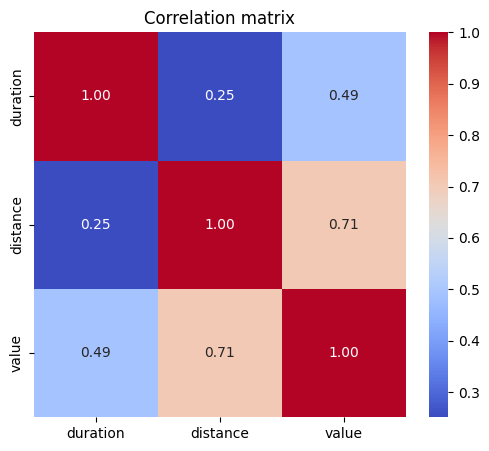

In [135]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

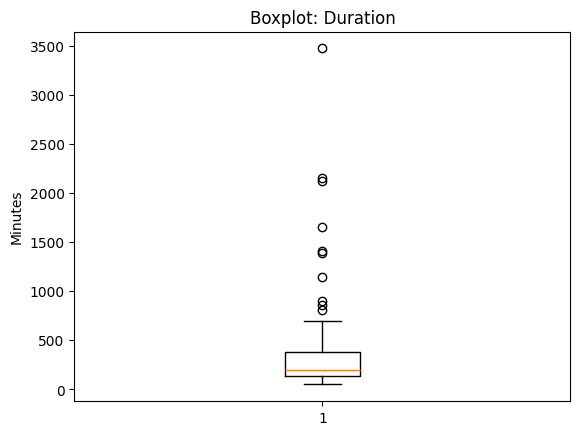

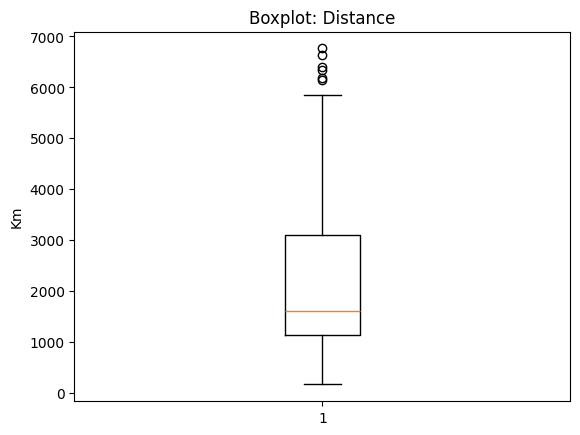

In [136]:
plt.figure()
plt.boxplot(tickets_copy['duration'])
plt.title('Boxplot: Duration')
plt.ylabel('Minutes')
plt.show()

plt.figure()
plt.boxplot(tickets_copy['distance'])
plt.title('Boxplot: Distance')
plt.ylabel('Km')
plt.show()

In [137]:
Q1 = tickets_copy['duration'].quantile(0.25)
Q3 = tickets_copy['duration'].quantile(0.75)
IQR = Q3 - Q1

outliers = tickets_copy[tickets_copy['duration'] > Q3 + 1.5 * IQR]

outlier_iata = outliers['destination']
outliers[['destination', 'duration']].sort_values('duration', ascending=False)

,destination,duration
233496,SWT,3475
239055,GVN,2155
116959,IWA,2125
247339,PYJ,1660
239224,NNM,1415
233387,URJ,1390
120347,KLF,1145
247448,ODO,900
204622,AAQ,860
248538,IAA,810


In [138]:
tickets = tickets[~tickets['destination'].isin(outliers['destination'])]

In [139]:
cities_iata_from_tickets = set(tickets['destination'].to_list())
overall_cities = set(cities_prepared['IATA_code'].to_list())

In [140]:
tickets_copy = tickets.copy()
tickets_copy = tickets_copy[(tickets_copy['market'] == 'ru') & (tickets_copy['currency'] == 'rub')]

tickets_copy = (
    tickets_copy
    .sort_values('distance')
    .drop_duplicates(subset='destination', keep='first')
)

In [141]:
cities_iata_from_tickets_dict = {}

for i in cities_iata_from_tickets:
    string = cities_prepared[cities_prepared['IATA_code'] == i]
    ticket_string = tickets_copy[(tickets_copy['destination'] == i)]
    cities_iata_from_tickets_dict[
        string['name'].to_string().split()[1]
    ] = {'lon': string['lon'].to_string().split()[1], 'lat': string['lat'].to_string().split()[1], 'distance': ticket_string['distance'].to_string().split()[1]}
    
print(cities_iata_from_tickets_dict)

{'Кызыл': {'lon': '94.46667', 'lat': '51.7', 'distance': '3654'}, 'Когалым': {'lon': '74.53361', 'lat': '62.19583', 'distance': '2224'}, 'Братск': {'lon': '101.816666', 'lat': '56.36667', 'distance': '3838'}, 'Тамбов': {'lon': '41.433334', 'lat': '52.716667', 'distance': '378'}, 'Ноябрьск': {'lon': '75.29459', 'lat': '63.17673', 'distance': '2238'}, 'Элиста': {'lon': '44.333332', 'lat': '46.36667', 'distance': '1169'}, 'Нижневартовск': {'lon': '76.49145', 'lat': '60.9476', 'distance': '2301'}, 'Южно-Сахалинск': {'lon': '142.75', 'lat': '46.966667', 'distance': '6636'}, 'Саранск': {'lon': '45.166668', 'lat': '54.166668', 'distance': '532'}, 'Великий': {'lon': '46.316666', 'lat': '60.766666', 'distance': '743'}, 'Чита': {'lon': '113.3', 'lat': '52.033333', 'distance': '4725'}, 'Тюмень': {'lon': '65.35024', 'lat': '57.181828', 'distance': '1704'}, 'Ижевск': {'lon': '53.466667', 'lat': '56.833332', 'distance': '975'}, 'Калининград': {'lon': '20.586645', 'lat': '54.882656', 'distance': '105

In [142]:
other_cities_dict = {}

for i in (overall_cities - cities_iata_from_tickets):
    string = cities_prepared[cities_prepared['IATA_code'] == i]
    other_cities_dict[
        string['name'].to_string().split()[1]
    ] = {'lon': string['lon'].to_string().split()[1], 'lat': string['lat'].to_string().split()[1]}
print(other_cities_dict)

{'Николаевск-на-Амуре': {'lon': '140.73333', 'lat': '53.15'}, 'Комсомольск-на-Амуре': {'lon': '136.95', 'lat': '50.4'}, 'Инта': {'lon': '60.1', 'lat': '66.066666'}, 'Дальнегорск': {'lon': '135.61667', 'lat': '44.56667'}, 'Йошкар-Ола': {'lon': '47.9', 'lat': '56.716667'}, 'Олёкминск': {'lon': '120.416667', 'lat': '60.366667'}, 'Ростов-на-Дону': {'lon': '39.75', 'lat': '47.25'}, 'Белгород': {'lon': '36.65', 'lat': '50.63333'}, 'Тарко-Сале': {'lon': '77.797356', 'lat': '64.92134'}, 'Калуга': {'lon': '36.266666', 'lat': '54.5'}, 'Таганрог': {'lon': '38.864017', 'lat': '47.243378'}, 'Усть-Кут': {'lon': '105.73333', 'lat': '56.85'}, 'Воронеж': {'lon': '39.226997', 'lat': '51.812355'}, 'Липецк': {'lon': '39.6', 'lat': '52.61667'}, 'Северо-Курильск': {'lon': '156.122523', 'lat': '50.666387'}, 'Тында': {'lon': '124.73333', 'lat': '55.283333'}, 'Усть-Илимск': {'lon': '102.55', 'lat': '58.13333'}, 'Никольское': {'lon': '166.045', 'lat': '55.177502'}, 'Старый': {'lon': '37.76667', 'lat': '51.32833

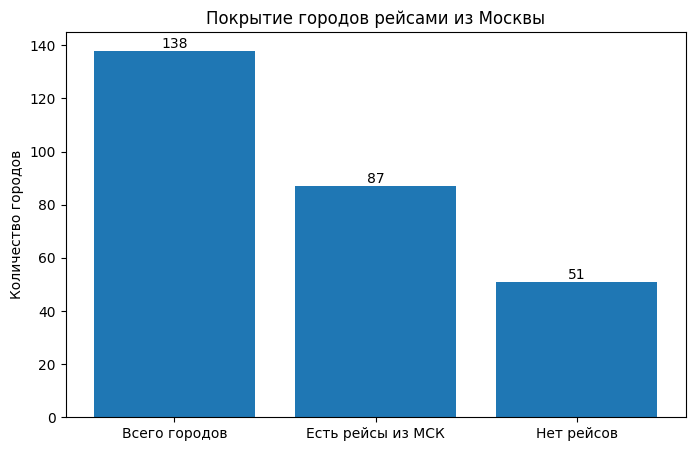

In [143]:
labels = ['Всего городов', 'Есть рейсы из МСК', 'Нет рейсов']
values = [len(overall_cities), len(cities_iata_from_tickets), len(overall_cities) - len(cities_iata_from_tickets)]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)

plt.title('Покрытие городов рейсами из Москвы')
plt.ylabel('Количество городов')

for i, v in enumerate(values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [144]:
import plotly.graph_objects as go

def plot_cities_from_dicts(cities_iata_from_tickets_dict, other_cities_dict):
    fig = go.Figure()

    lt_1000_lons, lt_1000_lats, lt_1000_text = [], [], []
    lt_2000_lons, lt_2000_lats, lt_2000_text = [], [], []
    lt_4000_lons, lt_4000_lats, lt_4000_text = [], [], []
    ge_4000_lons, ge_4000_lats, ge_4000_text = [], [], []

    if cities_iata_from_tickets_dict:
        for city, vals in cities_iata_from_tickets_dict.items():
            try:
                distance = float(vals["distance"])
            except:
                continue
            lat = float(vals["lat"])
            lon = float(vals["lon"])

            if distance < 1000:
                lt_1000_lons.append(lon)
                lt_1000_lats.append(lat)
                lt_1000_text.append(city)
            elif distance < 2000:
                lt_2000_lons.append(lon)
                lt_2000_lats.append(lat)
                lt_2000_text.append(city)
            elif distance < 4000:
                lt_4000_lons.append(lon)
                lt_4000_lats.append(lat)
                lt_4000_text.append(city)
            else:
                ge_4000_lons.append(lon)
                ge_4000_lats.append(lat)
                ge_4000_text.append(city)

    if lt_1000_lons:
        fig.add_trace(go.Scattermapbox(
            mode="markers+text",
            lon=lt_1000_lons,
            lat=lt_1000_lats,
            text=lt_1000_text,
            textposition="top center",
            marker=dict(size=9, color="green"),
            name="< 1000 км"
        ))

    if lt_2000_lons:
        fig.add_trace(go.Scattermapbox(
            mode="markers+text",
            lon=lt_2000_lons,
            lat=lt_2000_lats,
            text=lt_2000_text,
            textposition="top center",
            marker=dict(size=9, color="blue"),
            name="1000–2000 км"
        ))

    if lt_4000_lons:
        fig.add_trace(go.Scattermapbox(
            mode="markers+text",
            lon=lt_4000_lons,
            lat=lt_4000_lats,
            text=lt_4000_text,
            textposition="top center",
            marker=dict(size=9, color="purple"),
            name="2000–4000 км"
        ))

    if ge_4000_lons:
        fig.add_trace(go.Scattermapbox(
            mode="markers+text",
            lon=ge_4000_lons,
            lat=ge_4000_lats,
            text=ge_4000_text,
            textposition="top center",
            marker=dict(size=9, color="black"),
            name="> 4000 км"
        ))

    if other_cities_dict:
        red_names = list(other_cities_dict.keys())
        red_lons = [float(v["lon"]) for v in other_cities_dict.values()]
        red_lats = [float(v["lat"]) for v in other_cities_dict.values()]

        fig.add_trace(go.Scattermapbox(
            mode="markers+text",
            lon=red_lons,
            lat=red_lats,
            text=red_names,
            textposition="top center",
            marker=dict(size=8, color="red"),
            name="Нет рейсов из МСК"
        ))

    fig.update_layout(
        mapbox=dict(
            style="carto-positron",
            zoom=3
        ),
        margin=dict(l=0, r=0, t=40, b=0),
        title="Города по расстоянию от Москвы",
        height=800
    )

    fig.show()


plot_cities_from_dicts(cities_iata_from_tickets_dict, other_cities_dict)

/var/folders/g4/hthm8mbd7vd_zzj55zdrvhrr0000gn/T/ipykernel_4881/773240187.py:38: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
/var/folders/g4/hthm8mbd7vd_zzj55zdrvhrr0000gn/T/ipykernel_4881/773240187.py:49: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
/var/folders/g4/hthm8mbd7vd_zzj55zdrvhrr0000gn/T/ipykernel_4881/773240187.py:60: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
/var/folders/g4/hthm8mbd7vd_zzj55zdrvhrr0000gn/T/ipykernel_4881/773240187.py:71: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Sca

In [146]:
train_copy_tickets = tickets[(tickets['currency'] == 'rub') & (tickets['market'] == 'ru')]

In [148]:
train_copy_tickets.reset_index(inplace=True)

In [161]:
from datetime import datetime

def get_day_type(date_str):
    d = datetime.strptime(date_str, "%Y-%m-%d")
    return True if d.weekday() >= 5 else False

train_copy_tickets['workday'] = train_copy_tickets['depart_date'].apply(get_day_type)
train_copy_tickets

/var/folders/g4/hthm8mbd7vd_zzj55zdrvhrr0000gn/T/ipykernel_4881/1481408845.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_copy_tickets['workday'] = train_copy_tickets['depart_date'].apply(get_day_type)


,index,depart_date,origin,destination,gate,trip_class,value,duration,distance,market,currency,rate,workday
0,60,2026-06-01,MOW,LED,Kupi.com,0,3377,90,624,ru,rub,1.0,False
1,61,2026-06-03,MOW,LED,Kupi.com,0,3379,90,598,ru,rub,1.0,False
2,62,2026-06-06,MOW,LED,Kupi.com,0,3879,90,624,ru,rub,1.0,True
3,63,2026-06-04,MOW,LED,Т-Банк,0,3879,90,624,ru,rub,1.0,False
4,64,2026-06-02,MOW,LED,Kupi.com,0,3879,90,598,ru,rub,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010,247576,2026-06-15,MOW,PWE,Kupi.com,0,50389,700,5579,ru,rub,1.0,False
2011,247577,2026-06-03,MOW,PWE,S7 Airlines,0,50902,850,5586,ru,rub,1.0,False
2012,247578,2026-06-02,MOW,PWE,S7 Airlines,0,54039,1900,5586,ru,rub,1.0,False
2013,247580,2026-06-14,MOW,PWE,OneTwoTrip,0,56432,2110,5579,ru,rub,1.0,True


In [169]:
train_copy_tickets_import = pd.merge(train_copy_tickets, cities_prepared, how='left', left_on='destination', right_on='IATA_code')

In [170]:
train_copy_tickets_import = (
    train_copy_tickets_import[['depart_date', 'value', 'workday', 'name']]
    .groupby(['name', 'workday'])
    .agg({'value': 'mean'})
    .reset_index()
)

train_copy_tickets_import

,name,workday,value
0,Абакан,False,17895.545455
1,Абакан,True,18512.000000
2,Анадырь,False,29478.111111
3,Анадырь,True,28106.500000
4,Архангельск,False,5473.272727
...,...,...,...
163,Южно-Сахалинск,False,18647.909091
164,Южно-Сахалинск,True,23145.000000
165,Якутск,False,21107.142857
166,Якутск,True,21743.800000


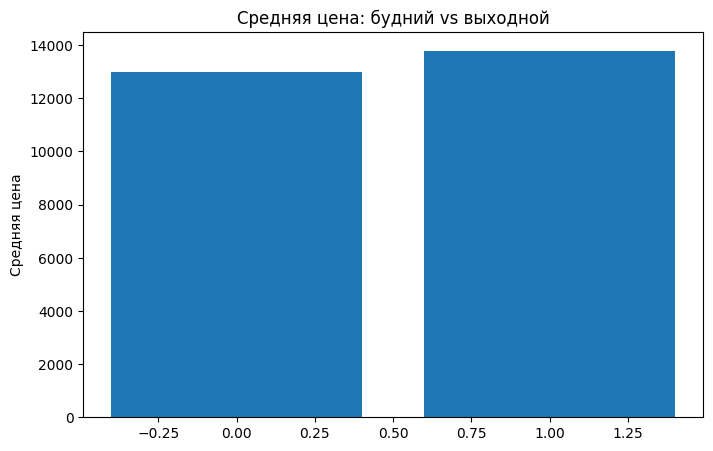

In [176]:
day_price = (
    train_copy_tickets_import
    .groupby('workday', as_index=False)
    .agg({'value': 'mean'})
)

plt.figure(figsize=(8, 5))
plt.bar(day_price['workday'], day_price['value'])
plt.title('Средняя цена: будний vs выходной')
plt.ylabel('Средняя цена')
plt.show()

In [177]:
train_copy_tickets_import.to_csv('../data/to_export.csv')